# Voltametria Cíclica Irreversível — Mecanismo EC

Considera-se uma transferência de elétrons reversível seguida por uma reação química homogênea acoplada (mecanismo EC):

$$O + ne^- \rightleftharpoons R$$

$$R \to P$$

Assumindo eletrodo planar, o transporte de massa é descrito pela segunda lei de Fick para cada espécie, com termos cinéticos para a reação química acoplada, para $0 \leq \tau \leq 2\tau_\lambda$ e $0 \leq y \leq 6\sqrt{D\tau_s}$:

$$\frac{\partial C_O}{\partial \tau} = D \frac{\partial^2 C_O}{\partial y^2}$$

$$\frac{\partial C_R}{\partial \tau} = D \frac{\partial^2 C_R}{\partial y^2} - k_f C_R $$


As condições iniciais assumem $R$ e $P$ inicialmente ausentes:

$$C_O(y, 0) = C_O^* \qquad C_R(y, 0) = 0$$

A difusão semi-infinita é aplicada no seio da solução:

$$\lim_{y \to \infty} C_O(y,\tau) = C_O^* \qquad \lim_{y \to \infty} C_R(y,\tau) = 0 $$

O potencial varia ciclicamente com o tempo:

$$E(\tau) = E_i + v\tau, \quad \text{se} \quad \tau \leq \tau_\lambda$$

$$E(\tau) = E_f - v(\tau - \tau_\lambda), \quad \text{se} \quad \tau_\lambda \leq \tau \leq 2\tau_\lambda$$

O balanço de fluxo e o equilíbrio de Nernst é imposto na interface eletrodo/solução, com $\theta = \exp\!\left(\frac{F}{RT}(E - E^0)\right)$:

$$C_O(0, \tau) = \theta C_R (0,\tau) \quad \text{para} \quad \tau > 0 \tag{1.3a}$$

$$ D_R\frac{\partial C_R(0, \tau)}{\partial y}+ D_O\frac{\partial C_O(0, \tau)}{\partial y}=0 \quad \text{para} \quad \tau > 0 \tag{1.3b}$$
Introduzindo as variáveis adimensionais, com $\tau_s = 1/fv$:

$$x = \frac{y}{\sqrt{D\tau_s}}, \quad t = \frac{\tau}{\tau_s}, \quad c_{O,R,P} = \frac{C_{O,R,P}}{C_O^*}, \quad \eta = f(E-E^0), \quad f = \frac{F}{RT}, \quad r_D = \frac{D_R}{D_O}$$

As constante de velocidade adimensional é definida como:

$$K_f = k_f \tau_s$$

As equações tornam-se, para $t \geq 0$ e $0 \leq x \leq 6$:

$$\frac{\partial c_O}{\partial t} = \frac{\partial^2 c_O}{\partial x^2} \tag{1.0a}$$

$$\frac{\partial c_R}{\partial t} = \frac{\partial^2 c_R}{\partial x^2} - K_f c_R  \tag{1.0b}$$


$$c_O(x, 0) = 1 \tag{1.1a}$$

$$c_R(x, 0) = 0 \tag{1.1b}$$

$$\lim_{x \to \infty} c_O(x,t) = 1 \tag{1.2a}$$

$$\lim_{x \to \infty} c_R(x,t) = 0 \tag{1.2b}$$

com $\eta = \eta_i + t$ e $\theta = \exp(f\eta)$:

$$c_O(0, t) = \theta c_R(0,t) \tag{1.3a}$$

$$\left( \frac{\partial c_R(0, t)}{\partial x} \right)_{x=0} = -\frac{1}{r_D} \left( \frac{\partial c_O(0,t)}{\partial x} \right)_{x=0} \tag{1.3b}$$


A densidade de corrente é proporcional ao fluxo difusional na superfície do eletrodo:

$$j(\tau) = nFD \left(\frac{\partial C_O}{\partial y}\right)_{y=0} = nFD\frac{C_O^*}{\sqrt{D\tau_s}} \left(\frac{\partial c_O}{\partial x}\right)_{x=0}$$

Definindo a corrente adimensional:

$$i(t) = \frac{j(\tau)\sqrt{D\tau_s}}{nFD C_O^*}$$

obtém-se:

$$i(t) = \left(\frac{\partial c_O}{\partial x}\right)_{x=0} \tag{3.0}$$

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [24]:
model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")
concentration_r = pybamm.Variable("Concentração de R", domain="electrolyte")


initial_potential      = pybamm.Parameter("Potencial Inicial [V]")
final_potential        = pybamm.Parameter("Potencial Final [V]")
standard_potential     = pybamm.Parameter("Potencial Padrão [V]")
scan_rate              = pybamm.Parameter("Velocidade de Varredura [V.s-1]")
faraday                = pybamm.Parameter("Constante de Faraday [C.mol-1]")
gas_constant           = pybamm.Parameter("Constante dos Gases [J.K-1.mol-1]")
temperature            = pybamm.Parameter("Temperatura [K]")
r_D                    = pybamm.Parameter("Razão entre os coeficientes de difusão")
equilibrium_constant   = pybamm.Parameter("Constante de Equilíbrio")
forward_rate_constant  = pybamm.Parameter("Constante de Velocidade Direta")
time_scale             = pybamm.Parameter("Escala de tempo [s]")

flux_o = -pybamm.grad(concentration_o)   # fluxo difusional de O
flux_r = -r_D*pybamm.grad(concentration_r)   # fluxo difusional de R

model.rhs = {
    concentration_o: -(1 / time_scale) * pybamm.div(flux_o),                                                    # lei de Fick para O
    concentration_r: -(1 / time_scale)*pybamm.div(flux_r) - forward_rate_constant * concentration_r           # Fick + reação química para R
}

# condições iniciais
theta_i = pybamm.exp(
    faraday * (initial_potential - standard_potential)
    / (gas_constant * temperature)
)

cO_initial = theta_i / (1 + theta_i)
cR_initial = 1 / (1 + theta_i)

model.initial_conditions = {
    concentration_o: cO_initial,  # c_O(x,0) = 1: O uniforme e adimensionalizado
    concentration_r: cR_initial,  # c_R(x,0) = 0: R inicialmente ausente
}

# condições de contorno
# esquerda (x=0): interface eletrodo/solução — equilíbrio de Nernst, potencial varia ciclicamente
# direita  (x=6): seio da solução            — difusão semi-infinita
nernst_factor         = faraday / (gas_constant * temperature)           # f = F/(RT)
total_time            = 2 * (final_potential - initial_potential) / scan_rate
cosine                = pybamm.cos((np.pi / total_time) * pybamm.t)
sine                  = pybamm.sin((np.pi / total_time) * pybamm.t)
applied_potential     = initial_potential + (2 * (final_potential - initial_potential) / np.pi) * pybamm.AbsoluteValue(pybamm.arctan(sine / cosine))
overpotential         = applied_potential - standard_potential
theta                 = pybamm.exp(nernst_factor * overpotential)        # θ = exp(f·η)

cR_surface = pybamm.boundary_value(concentration_r, "left")
cO_surface = theta * cR_surface # 1.3a
cO_gradient_surface = pybamm.boundary_gradient(concentration_o, "left")
cR_gradient_surface = -(1/r_D) * cO_gradient_surface #1.3b

model.boundary_conditions = {
    concentration_o: {
        "left":  (cO_surface, "Dirichlet"),  # equilíbrio de Nernst
        "right": (pybamm.Scalar(1), "Dirichlet"),  # difusão semi-infinita
    },
    concentration_r: {
        "left":  (cR_gradient_surface, "Neumann"),  # equilíbrio de Nernst
        "right": (pybamm.Scalar(0), "Dirichlet"),  # difusão semi-infinita
    },
}

model.variables = {
    "Concentração de O":  concentration_o,
    "Concentração de R":  concentration_r,
    "Fluxo de O":         flux_o,
    "Fluxo de R":         flux_r,
    "Potencial Aplicado": applied_potential,
}

param = pybamm.ParameterValues(
    {
        "Potencial Inicial [V]":              "[input]",
        "Potencial Final [V]":                "[input]",
        "Potencial Padrão [V]":               "[input]",
        "Velocidade de Varredura [V.s-1]":    "[input]",
        "Constante de Faraday [C.mol-1]":     96485.3,
        "Constante dos Gases [J.K-1.mol-1]":  8.31446,
        "Temperatura [K]":                    298.15,
        "Razão entre os coeficientes de difusão": 0.25,
        "Constante de Velocidade Direta":     "[input]",
        "Escala de tempo [s]": "[input]",
    }
)

## Geometria

In [25]:
# ── Geometria e Malha ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}

## Malha

In [26]:
submesh_types = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points = {x_variable: 400}
mesh            = pybamm.Mesh(geometry, submesh_types, variable_points)

## Discretização

In [27]:
# ── Discretização ─────────────────────────────────────────────────────────────

spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)

param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver

In [28]:
solver = pybamm.IDAKLUSolver(
    rtol=1e-8,
    atol=1e-10
)

## Gráfico Estático:

In [31]:
# ============================================================
# SIMULAÇÕES ESTÁTICAS — MECANISMO EC
# ============================================================

# Valores fixos da simulação
DEFAULT_INITIAL_POTENTIAL = 0.3
DEFAULT_FINAL_POTENTIAL = -0.3
DEFAULT_STANDARD_POTENTIAL = 0.0

# Constante de velocidade intermediária
DEFAULT_FORWARD_RATE_CONSTANT = .4

# Velocidade de varredura intermediária
DEFAULT_SCAN_RATE = -0.1

# Velocidades de varredura para o primeiro gráfico
scan_rates = [-0.02, -0.05, -0.1, -0.2, -0.5]

# Constantes de velocidade para o segundo gráfico
forward_rate_constants = [0.04, 0.4, 4.0, 40.0, 400.0]

# ============================================================
# 1. Efeito da velocidade de varredura
#    kf = constante
# ============================================================

currents_v = []
potentials_v = []

for scan_rate_i in scan_rates:

    # Escala temporal associada à velocidade de varredura
    tau_s_i = (
        8.31446 * 298.15
        / (96485.3 * abs(scan_rate_i))
    )

    # Tempo total de um ciclo
    final_time = (
        2
        * (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL)
        / scan_rate_i
    )

    time = np.linspace(0, final_time, 1000)

    solution = solver.solve(
        model,
        time,
        inputs={
            "Potencial Inicial [V]":
                DEFAULT_INITIAL_POTENTIAL,

            "Potencial Final [V]":
                DEFAULT_FINAL_POTENTIAL,

            "Potencial Padrão [V]":
                DEFAULT_STANDARD_POTENTIAL,

            "Velocidade de Varredura [V.s-1]":
                scan_rate_i,

            "Escala de tempo [s]":
                tau_s_i,

           "Constante de Velocidade Direta":
                DEFAULT_FORWARD_RATE_CONSTANT,
        }
    )

    flux_o_solution = solution["Fluxo de O"]
    applied_potential_solution = solution["Potencial Aplicado"]

    current = flux_o_solution(solution.t, x=0)
    potential = applied_potential_solution(solution.t)

    currents_v.append(current)
    potentials_v.append(potential)
    

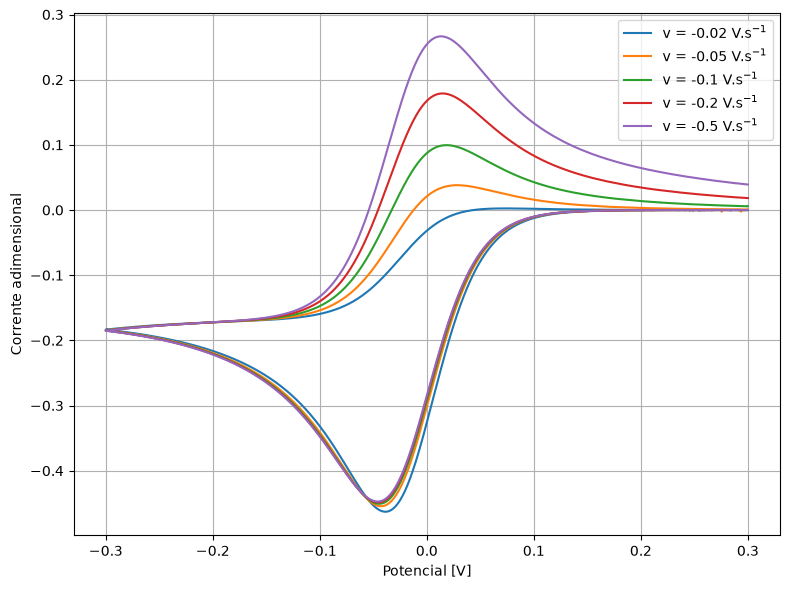

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

for scan_rate_i, current, potential in zip(
    scan_rates,
    currents_v,
    potentials_v
):
    ax.plot(
        potential,
        current,
        label=f"v = {scan_rate_i:g} V.s$^{{-1}}$"
    )

ax.set_xlabel("Potencial [V]")
ax.set_ylabel("Corrente adimensional")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

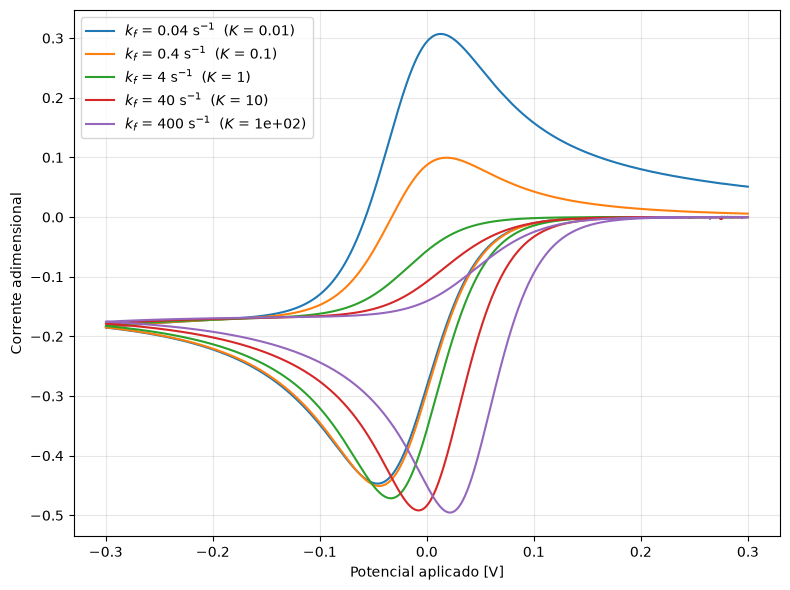

In [36]:
# ============================================================
# GRÁFICO 2 — Efeito da constante de velocidade química
# Velocidade de varredura fixa
# ============================================================

fixed_scan_rate = -0.1

forward_rate_constants = [0.04, 0.4, 4.0, 40.0, 400.0]

currents_kf = []
potentials_kf = []
K_values = []

for kf_i in forward_rate_constants:

    # Escala de tempo eletroquímica
    tau_s = (
        8.31446 * 298.15
        / (96485.3 * abs(fixed_scan_rate))
    )

    # Parâmetro adimensional de reação
    K_i = kf_i * tau_s
    K_values.append(K_i)

    # Tempo total da varredura
    final_time = (
        2 * (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL)
        / fixed_scan_rate
    )

    time = np.linspace(0, final_time, 1000)

    solution = solver.solve(
        model,
        time,
        inputs={
            "Potencial Inicial [V]": DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]": DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]": DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": fixed_scan_rate,
            "Escala de tempo [s]": tau_s,
            "Constante de Velocidade Direta": kf_i,
        }
    )

    flux_o_solution = solution["Fluxo de O"]
    applied_potential_solution = solution["Potencial Aplicado"]

    current = flux_o_solution(solution.t, x=0)
    potential = applied_potential_solution(solution.t)

    currents_kf.append(current)
    potentials_kf.append(potential)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for kf_i, K_i, potential, current in zip(
    forward_rate_constants,
    K_values,
    potentials_kf,
    currents_kf
):

    plt.plot(
        potential,
        current,
        label=fr"$k_f$ = {kf_i:g} s$^{{-1}}$  ($K$ = {K_i:.2g})"
    )

plt.xlabel("Potencial aplicado [V]")
plt.ylabel("Corrente adimensional")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico da esquerda mostra o efeito da constante de velocidade direta $k_f$ e, consequentemente, de $k_b$ no voltamograma cíclico, mantendo $K_{eq}=10$. Quando $k_f=0.1$ e $k_b=0.01$, o resultado se aproxima de um sistema reversível sem reação acoplada. Já quando $k_f$ apresenta um valor intermediário, a reação $R \rightleftharpoons P$ é mais rápida, consumindo $R$ mais rapidamente na solução. Isso reduz a concentração de $R$ disponível para reoxidação, diminuindo ou eliminando o pico anódico na varredura inversa. Quando $k_f=1000$ e, consequentemente, $k_b=100$, os potenciais de pico são deslocados e a corrente anódica volta a aumentar. Isto ocorre, pois o equilíbrio se reestabelece mais rapidamente, então conforme R é reoxidado, P rapidamente é convertido em R, impedindo seu esgotamento.

O gráfico da direita mostra o efeito da constante de equilíbrio $K_{eq}$. Valores altos de $K_{eq}$ favorecem termodinamicamente a formação de $P$, deslocando o potencial de pico para a direita e suprimindo o pico anódico. A comparação entre os dois gráficos permite distinguir efeitos cinéticos de efeitos termodinâmicos no voltamograma.

## Gráfico Interativo:

In [38]:
# ============================================================
# VOLTAMETRIA DIMENSIONAL INTERATIVA
# Parâmetros: velocidade de varredura e kf
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ------------------------------------------------------------
# Constantes físicas para reconstrução dimensional
# ------------------------------------------------------------

n = 1
C_star = 1.0       # mol.m-3
D_O = 1.0e-9       # m2.s-1

F = 96485.3        # C.mol-1
R = 8.31446        # J.mol-1.K-1
T = 298.15         # K


# ------------------------------------------------------------
# Função de simulação
# ------------------------------------------------------------

def simulate_ec(scan_rate, kf):

    # Escala de tempo eletroquímica
    tau_s = R * T / (n * F * abs(scan_rate))

    # Parâmetro adimensional da reação química
    K = kf * tau_s

    # Tempo total da varredura triangular
    final_time = (
        2 * (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL)
        / scan_rate
    )

    time = np.linspace(0, final_time, 1000)

    # Solução do modelo
    solution = solver.solve(
        model,
        time,
        inputs={
            "Potencial Inicial [V]": DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]": DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]": DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": scan_rate,
            "Escala de tempo [s]": tau_s,
             "Constante de Velocidade Direta": kf,
        }
    )

    # Variáveis de saída
    flux_o_solution = solution["Fluxo de O"]
    applied_potential_solution = solution["Potencial Aplicado"]

    # Corrente adimensional
    i_dimensionless = flux_o_solution(
        solution.t,
        x=0
    )

    # Potencial dimensional
    potential = applied_potential_solution(solution.t)

    # --------------------------------------------------------
    # Reconstrução da densidade de corrente dimensional
    # --------------------------------------------------------

    current_density = (
        n * F * C_star
        * np.sqrt(D_O / tau_s)
        * i_dimensionless
    )

    return potential, current_density, K


# ------------------------------------------------------------
# Função de atualização do gráfico
# ------------------------------------------------------------

def update_plot(scan_rate, kf):

    potential, current_density, K = simulate_ec(
        scan_rate,
        kf
    )

    plt.figure(figsize=(8, 6))

    plt.plot(
        potential,
        current_density,
        linewidth=2
    )

    plt.xlabel("Potencial aplicado [V]")
    plt.ylabel("Densidade de corrente [A m$^{-2}$]")

    plt.title(
        f"Voltametria ECE  |  "
        f"v = {scan_rate:.3f} V s$^{{-1}}  |  "
        f"$k_f$ = {kf:.3g} s$^{{-1}}$  |  "
        f"K = {K:.3g}"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Controles
# ------------------------------------------------------------

scan_rate_widget = widgets.FloatSlider(
    value=-0.10,
    min=-0.50,
    max=-0.02,
    step=0.01,
    description="v [V/s]:",
    continuous_update=False,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

kf_widget = widgets.FloatLogSlider(
    value=1.0,
    base=10,
    min=-2,
    max=3,
    step=0.1,
    description="kf [s⁻¹]:",
    continuous_update=False,
    readout_format=".2g",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

ui = widgets.VBox([
    scan_rate_widget,
    kf_widget
])

out = widgets.interactive_output(
    update_plot,
    {
        "scan_rate": scan_rate_widget,
        "kf": kf_widget
    }
)

display(ui, out)

Output()